# 01 — COX2 Dataset Inspection and Understanding

**Project:** Bioactive Molecule Prediction Using Extreme Gradient Boosting
**Based on:** Mustapha & Saeed (2016)
**Stage:** 1 — Dataset Inspection ONLY

This notebook does **not** perform any preprocessing, feature engineering, descriptor/fingerprint generation, or model training. Its only goal is to understand what the raw COX2 files actually contain, so that Stage 2 (preprocessing) can be designed correctly instead of guessed.

## Section 1 — Project Context

- **Project name:** Bioactive Molecule Prediction Using Extreme Gradient Boosting
- **Current dataset:** COX2 (a graph-structured chemical dataset, six text files — not a single CSV)
- **Purpose of this notebook:** Inspect and understand the raw COX2 files before any modeling decisions are made
- **Scope:** Dataset inspection only. No preprocessing, no descriptors, no fingerprints, no ML model.

Everything below is computed directly from the actual files — nothing is assumed or hard-coded.

## Section 2 — Import Libraries

We only need basic data-handling libraries for inspection. No RDKit, no ML libraries — there is no clear need for them at this stage.

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Display settings for readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print("Libraries imported successfully.")

Libraries imported successfully.


## Section 3 — Dataset Location

We expect the six COX2 files to be inside  in Colab.
We first confirm that all six expected files actually exist before doing anything else. If any file is missing, the notebook stops here with a clear error instead of continuing silently.

In [ ]:
# Change this path if your files are located elsewhere
DATA_DIR = Path("/content")

# The six files this dataset is supposed to have
expected_files = [
    "COX2_A.txt",
    "COX2_graph_indicator.txt",
    "COX2_graph_labels.txt",
    "COX2_node_labels.txt",
    "COX2_node_attributes.txt",
    "README.txt",
]

print("Dataset directory:", DATA_DIR.resolve())
print()

found_files = []
missing_files = []

for filename in expected_files:
    file_path = DATA_DIR / filename
    if file_path.exists():
        found_files.append(filename)
    else:
        missing_files.append(filename)

print("Files found:")
for f in found_files:
    print(" -", f)

print()
print("Files missing:")
if missing_files:
    for f in missing_files:
        print(" -", f)
else:
    print(" (none)")

Dataset directory: /content

Files found:
 - COX2_A.txt
 - COX2_graph_indicator.txt
 - COX2_graph_labels.txt
 - COX2_node_labels.txt
 - COX2_node_attributes.txt
 - README.txt

Files missing:
 (none)


In [ ]:
# Stop clearly if anything is missing, instead of silently continuing
if missing_files:
    raise FileNotFoundError(
        f"Missing required COX2 files: {missing_files}. "
        f"Please upload them into {DATA_DIR} before continuing."
    )
else:
    print("All six expected files are present. Safe to continue.")

All six expected files are present. Safe to continue.


## Section 4 — Inspect Every File

Before loading anything into pandas, let's look at each file at the raw text level: how many lines it has, what the first few lines look like, and what README says it represents. This avoids assuming a structure that isn't actually there.

In [ ]:
def peek_file(filename, n_lines=5):
    """Print basic info about a raw text file: line count and first few lines."""
    file_path = DATA_DIR / filename
    with open(file_path, "r") as f:
        lines = f.readlines()

    print(f"File: {filename}")
    print(f"Number of lines: {len(lines)}")
    print(f"First {n_lines} lines:")
    for line in lines[:n_lines]:
        print("  ", line.strip())
    print("-" * 60)
    return len(lines)

line_counts = {}
for filename in ["COX2_A.txt", "COX2_graph_indicator.txt", "COX2_graph_labels.txt",
                  "COX2_node_labels.txt", "COX2_node_attributes.txt"]:
    line_counts[filename] = peek_file(filename)

File: COX2_A.txt
Number of lines: 40578
First 5 lines:
   2, 1
   5, 1
   19, 1
   1, 2
   3, 2
------------------------------------------------------------
File: COX2_graph_indicator.txt
Number of lines: 19252
First 5 lines:
   1
   1
   1
   1
   1
------------------------------------------------------------
File: COX2_graph_labels.txt
Number of lines: 467
First 5 lines:
   -1
   -1
   1
   -1
   -1
------------------------------------------------------------
File: COX2_node_labels.txt
Number of lines: 19252
First 5 lines:
   6
   7
   6
   6
   6
------------------------------------------------------------
File: COX2_node_attributes.txt
Number of lines: 19252
First 5 lines:
   3.355228,  0.143395,  1.083854
   2.090028,  0.200695,  0.491354
   1.188228, -0.454505,  1.342654
   1.902628, -0.921605,  2.434354
   3.244428, -0.536105,  2.281354
------------------------------------------------------------


**What the README says each file contains (from the actual README.txt in this dataset):**

- `COX2_A.txt` — sparse (block diagonal) adjacency information for all graphs; each line is `(node_id, node_id)`
- `COX2_graph_indicator.txt` — one line per node; the value tells which graph that node belongs to
- `COX2_graph_labels.txt` — one line per graph; the class label of that graph
- `COX2_node_labels.txt` — one line per node; a label associated with that node
- `COX2_node_attributes.txt` — one line per node; comma-separated numerical attribute vector for that node

Let's read README.txt directly so we're not relying on a summary — the actual file content:

In [ ]:
with open(DATA_DIR / "README.txt", "r") as f:
    readme_text = f.read()

print(readme_text)

README for dataset COX2


=== Usage ===

This folder contains the following comma separated text files 
(replace DS by the name of the dataset):

n = total number of nodes
m = total number of edges
N = number of graphs

(1) 	DS_A.txt (m lines) 
	sparse (block diagonal) adjacency matrix for all graphs,
	each line corresponds to (row, col) resp. (node_id, node_id)

(2) 	DS_graph_indicator.txt (n lines)
	column vector of graph identifiers for all nodes of all graphs,
	the value in the i-th line is the graph_id of the node with node_id i

(3) 	DS_graph_labels.txt (N lines) 
	class labels for all graphs in the dataset,
	the value in the i-th line is the class label of the graph with graph_id i

(4) 	DS_node_labels.txt (n lines)
	column vector of node labels,
	the value in the i-th line corresponds to the node with node_id i

There are OPTIONAL files if the respective information is available:

(5) 	DS_edge_labels.txt (m lines; same size as DS_A_sparse.txt)
	labels for the edges in DS_A_spar

## Section 5 — COX2_A.txt (Adjacency / Connectivity)

This file lists `(node_id, node_id)` pairs. The README describes it as a **sparse block-diagonal adjacency matrix for all graphs combined** — meaning all 467 molecular graphs are stacked into one big adjacency list, and node IDs are shared across the whole dataset (not reset to 1 for each graph). This is why we cannot yet call each row a "unique chemical bond" without first checking things like symmetry and duplication.

In [ ]:
adjacency_df = pd.read_csv(DATA_DIR / "COX2_A.txt", header=None, names=["node_id_1", "node_id_2"])

print("Shape (records, columns):", adjacency_df.shape)
print()
print("First 5 records:")
print(adjacency_df.head())
print()
print("Data types:")
print(adjacency_df.dtypes)

Shape (records, columns): (40578, 2)

First 5 records:
   node_id_1  node_id_2
0          2          1
1          5          1
2         19          1
3          1          2
4          3          2

Data types:
node_id_1    int64
node_id_2    int64
dtype: object


In [ ]:
min_node_id = min(adjacency_df["node_id_1"].min(), adjacency_df["node_id_2"].min())
max_node_id = max(adjacency_df["node_id_1"].max(), adjacency_df["node_id_2"].max())

print("Minimum node ID appearing in COX2_A.txt:", min_node_id)
print("Maximum node ID appearing in COX2_A.txt:", max_node_id)

Minimum node ID appearing in COX2_A.txt: 1
Maximum node ID appearing in COX2_A.txt: 19252


In [ ]:
# Check whether the connectivity is symmetric:
# i.e., for every (a, b) pair, does (b, a) also appear?
edge_set = set(zip(adjacency_df["node_id_1"], adjacency_df["node_id_2"]))
reverse_edge_set = set(zip(adjacency_df["node_id_2"], adjacency_df["node_id_1"]))

symmetric_edges = edge_set.issuperset(reverse_edge_set)
print("Is every (a, b) matched by a (b, a)? ->", symmetric_edges)

# Check for self-loops: node connected to itself
self_loops = adjacency_df[adjacency_df["node_id_1"] == adjacency_df["node_id_2"]]
print("Number of self-loop records (node_id_1 == node_id_2):", len(self_loops))

Is every (a, b) matched by a (b, a)? -> True
Number of self-loop records (node_id_1 == node_id_2): 0


**What "sparse block-diagonal adjacency" means here:** all 467 graphs' connectivity is stored in one long list, using a single, shared numbering of node IDs across the whole dataset (not restarted per graph). If we imagine one giant adjacency matrix for all 19,252 nodes together, each individual molecule's connections would only occupy a small block along the diagonal of that matrix — hence "block diagonal." We are **not yet** asserting that each row is a unique chemical bond; that depends on whether edges are listed once or twice (symmetric) per bond, which the check above tells us directly from the data.

## Section 6 — COX2_graph_indicator.txt

This file has one line per node, and the value on line *i* is the graph ID that node *i* belongs to. This is what lets us map individual nodes back to the molecule (graph) they came from.

In [ ]:
graph_indicator = pd.read_csv(DATA_DIR / "COX2_graph_indicator.txt", header=None, names=["graph_id"])
graph_indicator.index = graph_indicator.index + 1  # node IDs start at 1, matching COX2_A.txt
graph_indicator.index.name = "node_id"

print("Total number of node records:", len(graph_indicator))
print("Minimum graph ID:", graph_indicator["graph_id"].min())
print("Maximum graph ID:", graph_indicator["graph_id"].max())
print("Number of unique graph IDs:", graph_indicator["graph_id"].nunique())

Total number of node records: 19252
Minimum graph ID: 1
Maximum graph ID: 467
Number of unique graph IDs: 467


In [ ]:
unique_graph_ids = sorted(graph_indicator["graph_id"].unique())
expected_range = list(range(1, graph_indicator["graph_id"].max() + 1))
graph_ids_continuous = (unique_graph_ids == expected_range)

print("Are graph IDs continuous from 1 to max, with no gaps? ->", graph_ids_continuous)

Are graph IDs continuous from 1 to max, with no gaps? -> True


In [ ]:
nodes_per_graph = graph_indicator.groupby("graph_id").size()

print("Nodes per graph — summary:")
print("  Minimum nodes in a graph:", nodes_per_graph.min())
print("  Maximum nodes in a graph:", nodes_per_graph.max())
print("  Average nodes per graph: %.2f" % nodes_per_graph.mean())
print()
print("First 10 graphs and their node counts:")
print(nodes_per_graph.head(10))

Nodes per graph — summary:
  Minimum nodes in a graph: 32
  Maximum nodes in a graph: 56
  Average nodes per graph: 41.22

First 10 graphs and their node counts:
graph_id
1     39
2     36
3     36
4     39
5     42
6     42
7     44
8     39
9     42
10    42
dtype: int64


In [ ]:
# Verify: number of graph_indicator records should equal number of node records (line_counts)
check_6 = len(graph_indicator) == line_counts["COX2_graph_indicator.txt"]
print("graph_indicator record count matches file line count:", check_6)

graph_indicator record count matches file line count: True


## Section 7 — COX2_graph_labels.txt

One label per graph. We deliberately do **not** rename `-1` / `+1` to "Active" / "Inactive" here — that mapping is not confirmed anywhere in the files we have, so calling it that would be an unverified assumption.

In [ ]:
graph_labels = pd.read_csv(DATA_DIR / "COX2_graph_labels.txt", header=None, names=["label"])
graph_labels.index = graph_labels.index + 1
graph_labels.index.name = "graph_id"

print("Number of graph labels:", len(graph_labels))
print("Unique label values:", sorted(graph_labels["label"].unique()))

Number of graph labels: 467
Unique label values: [np.int64(-1), np.int64(1)]


In [ ]:
label_counts = graph_labels["label"].value_counts()
label_percent = graph_labels["label"].value_counts(normalize=True) * 100

label_summary = pd.DataFrame({
    "Count": label_counts,
    "Percentage": label_percent.round(2)
})

print("Class distribution (raw label values, not renamed):")
print(label_summary)

Class distribution (raw label values, not renamed):
       Count  Percentage
label                   
-1       365       78.16
 1       102       21.84


**Important:** the values above are exactly the raw labels found in `COX2_graph_labels.txt`. We have **not** confirmed which value means "active" and which means "inactive" — that would need to come from the dataset documentation or the original paper, not be assumed from the sign of the number. Treat this as **not yet verified.**

## Section 8 — COX2_node_labels.txt

One label per node (not per graph). This is a different, finer-grained property than the graph label from Section 7 — the graph label describes the *whole molecule*, while the node label describes a *single node inside* that molecule.

In [ ]:
node_labels = pd.read_csv(DATA_DIR / "COX2_node_labels.txt", header=None, names=["node_label"])
node_labels.index = node_labels.index + 1
node_labels.index.name = "node_id"

print("Number of node labels:", len(node_labels))
print("Unique node-label values:", sorted(node_labels["node_label"].unique()))
print()
print("Frequency of each node label:")
print(node_labels["node_label"].value_counts().sort_index())

Number of node labels: 19252
Unique node-label values: [np.int64(1), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(16), np.int64(17), np.int64(35)]

Frequency of each node label:
node_label
1     7019
6     8543
7      896
8     1138
9      932
16     537
17     171
35      16
Name: count, dtype: int64


In [ ]:
check_8 = len(node_labels) == len(graph_indicator)
print("Number of node labels matches number of nodes:", check_8)

Number of node labels matches number of nodes: True


**Graph-level label vs. node-level label, in this dataset:**
- `graph_labels`: one value per molecule (467 values total) — describes the whole graph.
- `node_labels`: one value per node (19,252 values total) — describes an individual node within a graph.

We do **not yet know** what a node label numerically represents chemically (e.g. whether it encodes an atom type) — that is listed as unverified in Section 14.

In [ ]:
node_attributes = pd.read_csv(DATA_DIR / "COX2_node_attributes.txt", header=None)
node_attributes.columns = [f"Node Attribute {i+1}" for i in range(node_attributes.shape[1])]
node_attributes.index = node_attributes.index + 1
node_attributes.index.name = "node_id"

print("Number of rows:", node_attributes.shape[0])
print("Number of columns (attributes per node):", node_attributes.shape[1])
print()
print("Data types:")
print(node_attributes.dtypes)
print()
print("Missing values per column:")
print(node_attributes.isnull().sum())

Number of rows: 19252
Number of columns (attributes per node): 3

Data types:
Node Attribute 1    float64
Node Attribute 2    float64
Node Attribute 3    float64
dtype: object

Missing values per column:
Node Attribute 1    0
Node Attribute 2    0
Node Attribute 3    0
dtype: int64


In [ ]:
print("First 5 rows:")
print(node_attributes.head())
print()
print("Summary statistics:")
print(node_attributes.describe())

First 5 rows:
         Node Attribute 1  Node Attribute 2  Node Attribute 3
node_id                                                      
1                3.355228          0.143395          1.083854
2                2.090028          0.200695          0.491354
3                1.188228         -0.454505          1.342654
4                1.902628         -0.921605          2.434354
5                3.244428         -0.536105          2.281354

Summary statistics:
       Node Attribute 1  Node Attribute 2  Node Attribute 3
count      1.925200e+04      1.925200e+04      1.925200e+04
mean       6.752545e-10      2.004986e-08      2.649075e-09
std        3.206889e+00      1.728960e+00      2.346525e+00
min       -8.848138e+00     -5.886349e+00     -7.226169e+00
25%       -2.577264e+00     -1.333969e+00     -1.510698e+00
50%        9.279905e-01     -2.315080e-01      2.129240e-01
75%        2.064945e+00      8.974590e-01      1.803675e+00
max        8.568727e+00      5.796213e+00      6.77

In [ ]:
expected_three_attributes = (node_attributes.shape[1] == 3)
print("Does the data confirm 3 numerical attributes per node?", expected_three_attributes)

Does the data confirm 3 numerical attributes per node? True


We are calling these columns **Node Attribute 1 / 2 / 3** rather than giving them chemical names, because no chemical meaning for these columns is documented in the files we have. Assigning names like "electronegativity" or "partial charge" at this point would be a guess, not a verified fact.

## Section 10 — File Consistency Check

Here we cross-check the files against each other. Every result below is calculated, not hard-coded.

In [ ]:
num_nodes = len(graph_indicator)
num_graphs = len(graph_labels)

checks = {}

# 1. graph_indicator records == number of nodes (by definition, but confirm against raw line count)
checks["Node count consistency (graph_indicator vs file lines)"] = (
    len(graph_indicator) == line_counts["COX2_graph_indicator.txt"]
)

# 2. node_labels == number of nodes
checks["Node label consistency (node_labels count == node count)"] = (
    len(node_labels) == num_nodes
)

# 3. node_attribute rows == number of nodes
checks["Node attribute consistency (node_attributes rows == node count)"] = (
    len(node_attributes) == num_nodes
)

# 4. graph_labels == number of graphs (i.e. == number of unique graph IDs)
checks["Graph label consistency (graph_labels count == unique graph IDs)"] = (
    len(graph_labels) == graph_indicator["graph_id"].nunique()
)

# 5. Maximum graph ID corresponds to number of graphs
checks["Graph ID consistency (max graph_id == number of graphs)"] = (
    graph_indicator["graph_id"].max() == num_graphs
)

# 6. Node IDs in COX2_A.txt are within the valid node range [1, num_nodes]
valid_range = adjacency_df[["node_id_1", "node_id_2"]].apply(
    lambda col: col.between(1, num_nodes)
)
checks["Adjacency node ID validity (all node IDs within [1, num_nodes])"] = bool(valid_range.all().all())

# 7. Every node belongs to a valid graph (graph_id must exist in graph_labels index)
valid_graph_ids = set(graph_labels.index)
checks["Every node maps to a valid graph ID"] = graph_indicator["graph_id"].isin(valid_graph_ids).all()

# 8. Every graph has a graph-level label (no missing values)
checks["Every graph has a graph-level label (no NaNs)"] = graph_labels["label"].notnull().all()

print(f"{'CHECK':<65}{'STATUS'}")
print("-" * 75)
for check_name, result in checks.items():
    status = "PASS" if result else "FAIL"
    print(f"{check_name:<65}{status}")

CHECK                                                            STATUS
---------------------------------------------------------------------------
Node count consistency (graph_indicator vs file lines)           PASS
Node label consistency (node_labels count == node count)         PASS
Node attribute consistency (node_attributes rows == node count)  PASS
Graph label consistency (graph_labels count == unique graph IDs) PASS
Graph ID consistency (max graph_id == number of graphs)          PASS
Adjacency node ID validity (all node IDs within [1, num_nodes])  PASS
Every node maps to a valid graph ID                              PASS
Every graph has a graph-level label (no NaNs)                    PASS


## Section 11 — Graph-Level Summary

A single summary table pulling together everything computed so far.

In [ ]:
summary = {
    "Number of graphs": num_graphs,
    "Number of nodes": num_nodes,
    "Number of adjacency records (COX2_A.txt lines)": len(adjacency_df),
    "Number of graph labels": len(graph_labels),
    "Number of node labels": len(node_labels),
    "Number of node attribute rows": len(node_attributes),
    "Number of node attributes per node": node_attributes.shape[1],
    "Unique graph labels": sorted(graph_labels["label"].unique()),
    "Minimum nodes per graph": int(nodes_per_graph.min()),
    "Maximum nodes per graph": int(nodes_per_graph.max()),
    "Average nodes per graph": round(float(nodes_per_graph.mean()), 2),
}

summary_df = pd.DataFrame(list(summary.items()), columns=["Metric", "Value"])
summary_df

,Metric,Value
0,Number of graphs,467
1,Number of nodes,19252
2,Number of adjacency records (COX2_A.txt lines),40578
3,Number of graph labels,467
4,Number of node labels,19252
5,Number of node attribute rows,19252
6,Number of node attributes per node,3
7,Unique graph labels,"[-1, 1]"
8,Minimum nodes per graph,32
9,Maximum nodes per graph,56


## Section 12 — Inspect One Graph (Graph 1)

Let's zoom into a single molecule (Graph 1) and look at its raw representation: which nodes belong to it, their labels and attributes, and which edges connect them. This is purely to understand the raw structure — **not** a chemical reconstruction, and **not** a SMILES conversion.

In [ ]:
GRAPH_ID_TO_INSPECT = 1

# Which nodes belong to this graph?
nodes_in_graph = graph_indicator[graph_indicator["graph_id"] == GRAPH_ID_TO_INSPECT].index.tolist()

print(f"Graph ID: {GRAPH_ID_TO_INSPECT}")
print(f"Number of nodes in this graph: {len(nodes_in_graph)}")
print(f"Node IDs: {nodes_in_graph}")

Graph ID: 1
Number of nodes in this graph: 39
Node IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]


In [ ]:
print("Node labels for this graph:")
print(node_labels.loc[nodes_in_graph])

Node labels for this graph:
         node_label
node_id            
1                 6
2                 7
3                 6
4                 6
5                 6
6                 6
7                 6
8                 6
9                 6
10                6
11                6
12                6
13                6
14                6
15                6
16                6
17                6
18                9
19                6
20               16
21                8
22                8
23                6
24                1
25                1
26                1
27                1
28                1
29                1
30                1
31                1
32                1
33                1
34                1
35                1
36                1
37                1
38                1
39                1


In [ ]:
print("Node attributes for this graph:")
print(node_attributes.loc[nodes_in_graph])

Node attributes for this graph:
         Node Attribute 1  Node Attribute 2  Node Attribute 3
node_id                                                      
1                3.355228          0.143395          1.083854
2                2.090028          0.200695          0.491354
3                1.188228         -0.454505          1.342654
4                1.902628         -0.921605          2.434354
5                3.244428         -0.536105          2.281354
6               -0.267772         -0.529905          1.167754
7                1.782528          0.785495         -0.777046
8               -0.939372          0.369895          0.327054
9               -2.327872          0.303795          0.179254
10              -3.052272         -0.656005          0.890254
11              -2.398972         -1.556705          1.734554
12              -1.009972         -1.485405          1.877054
13               2.019628          2.148795         -1.004646
14               1.712828          2.7

In [ ]:
# Edges where BOTH endpoints belong to this graph's node set
node_set = set(nodes_in_graph)
edges_in_graph = adjacency_df[
    adjacency_df["node_id_1"].isin(node_set) & adjacency_df["node_id_2"].isin(node_set)
]

print(f"Number of connectivity records involving Graph {GRAPH_ID_TO_INSPECT}: {len(edges_in_graph)}")
print(edges_in_graph)

Number of connectivity records involving Graph 1: 82
    node_id_1  node_id_2
0           2          1
1           5          1
2          19          1
3           1          2
4           3          2
..        ...        ...
77         19         35
78         19         36
79         23         37
80         23         38
81         23         39

[82 rows x 2 columns]


This shows how one molecule is represented in the raw dataset: a set of node IDs (with a graph label attached at the graph level, and a node label plus 3 numeric attributes at the node level), plus a set of `(node_id, node_id)` connectivity pairs among just those nodes. Turning this into an RDKit molecule or a chemical structure is **not attempted here** — that decision belongs to Stage 2, after we've confirmed exactly what the node labels/attributes represent.

## Section 13 — Simple Visualization

Two simple plots: how node counts are distributed across graphs, and the class distribution of graph labels.

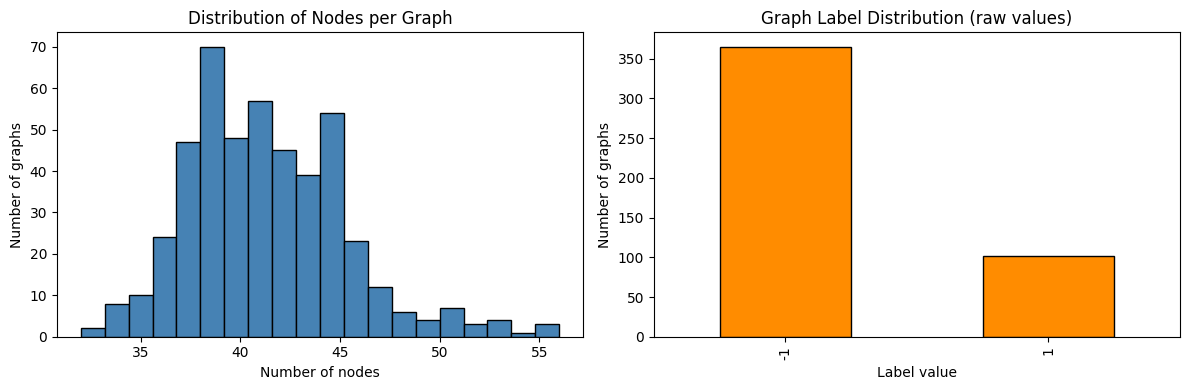

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of nodes per graph
axes[0].hist(nodes_per_graph, bins=20, color="steelblue", edgecolor="black")
axes[0].set_title("Distribution of Nodes per Graph")
axes[0].set_xlabel("Number of nodes")
axes[0].set_ylabel("Number of graphs")

# Class distribution of graph labels
label_counts.sort_index().plot(kind="bar", ax=axes[1], color="darkorange", edgecolor="black")
axes[1].set_title("Graph Label Distribution (raw values)")
axes[1].set_xlabel("Label value")
axes[1].set_ylabel("Number of graphs")

plt.tight_layout()
plt.show()

## Section 14 — What We Know vs What We Don't Know

### VERIFIED FROM DATA

- The exact number of graphs (see Section 11 summary table, computed from the data — not assumed)
- The exact number of nodes (computed, not assumed)
- The exact number of adjacency records in `COX2_A.txt`
- The number of node attributes per node (computed from actual column count, Section 9)
- The unique graph label values and their counts (Section 7)
- The unique node label values and their counts (Section 8)
- That `graph_indicator`, `node_labels`, and `node_attributes` all have one record per node, and that this count matches across files (Section 10)
- That all node IDs referenced in `COX2_A.txt` fall inside the valid node ID range (Section 10)
- That every node maps to a graph ID that has a corresponding entry in `graph_labels` (Section 10)
- The minimum, maximum, and average number of nodes per graph (Section 6/11)
- Whether the adjacency file is symmetric and whether self-loops exist (Section 5)

### NOT YET VERIFIED

- The exact semantic meaning of the graph labels (whether `-1`/`+1` correspond to "inactive"/"active", or the reverse — this is **not** established anywhere in the six files themselves)
- The chemical meaning of the node labels (e.g., whether they encode atom type, hybridization, or something else)
- The chemical meaning of the three node attributes (e.g., whether they are partial charge, coordinates, or another physicochemical property)
- Whether/how this graph representation should be converted into molecular descriptors or fingerprints for the XGBoost pipeline described in the base paper
- Whether RDKit can be directly applied to this representation, and if so, how
- The exact relationship between this publicly available COX2 graph dataset and the specific processed COX2 data used in Mustapha & Saeed (2016) — they may not be identical

These open questions should be resolved (via README research, the original paper, or the dataset's originating publication) **before** Stage 2 preprocessing decisions are made.

## Section 15 — Stage 1 Conclusion

**What did we learn about the COX2 dataset?**

The COX2 dataset is not a flat table of molecules with pre-computed features. It is a **graph-structured dataset**, where each molecule is one graph made of nodes (atoms, most likely, but not yet confirmed) connected by edges (from `COX2_A.txt`), with a single class label attached to the whole graph. All 467 graphs' nodes and edges are stored together in shared files using one continuous node numbering, rather than as 467 separate files. We've now confirmed the actual counts, checked that all six files are internally consistent with each other, and looked closely at how one single molecule (Graph 1) is represented in this raw form.

**Why can we now move to preprocessing?**

Because we understand exactly what raw material we're working with — how many graphs, how many nodes, how each file relates to the others, and what is/isn't confirmed about what the numbers mean — Stage 2 preprocessing can now be designed around the *actual* structure of this dataset, rather than being forced into an assumed tabular ML pipeline. Stage 2 will need to address the "Not Yet Verified" items above, especially how to turn each graph into the kind of feature vector an XGBoost model expects.

No preprocessing has been performed in this notebook.